In [1]:
# Re-import necessary packages after reset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import scipy.stats as stats


In [2]:
# Reload the uploaded file
energy_data_path = "../Results/firstResults/energy_calculated.csv"
energy_df = pd.read_csv(energy_data_path)

# Load Energy of idle 
energy_idle_data_path = "../Results/firstResults/energyidle_calculated.csv"
energy_idle_df = pd.read_csv(energy_idle_data_path)

In [3]:
# Display structure and first few rows
energy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   category                     1260 non-null   int64  
 1   framework                    1260 non-null   object 
 2   ID                           1260 non-null   object 
 3   event                        1260 non-null   object 
 4   number_of_iterations_pr_run  1260 non-null   int64  
 5   energy_pr_run                1260 non-null   float64
 6   energy                       1260 non-null   float64
 7   time_pr_run                  1260 non-null   int64  
 8   time                         1260 non-null   float64
 9   start_time                   1260 non-null   object 
 10  action_category_no           1260 non-null   int64  
 11  action_category              1260 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 118.3+ KB


In [4]:
energy_df

,category,framework,ID,event,number_of_iterations_pr_run,energy_pr_run,energy,time_pr_run,time,start_time,action_category_no,action_category
0,1,Nightwatch,Nightwatch,NightwatchEC/test/action1.js,140,51.700250,0.369287,17487,124.907143,1970-01-01 00:02:46.228,0,refresh
1,2,Nightwatch,Nightwatch,NightwatchEC/test/action1.js,140,40.853250,0.291809,13876,99.114286,1970-01-01 00:05:04.227,0,refresh
2,3,Nightwatch,Nightwatch,NightwatchEC/test/action1.js,140,40.046875,0.286049,13850,98.928571,1970-01-01 00:07:18.228,0,refresh
3,4,Nightwatch,Nightwatch,NightwatchEC/test/action1.js,140,40.374700,0.288391,13840,98.857143,1970-01-01 00:09:31.227,0,refresh
4,5,Nightwatch,Nightwatch,NightwatchEC/test/action1.js,140,40.922375,0.292303,13779,98.421429,1970-01-01 00:11:45.228,0,refresh
...,...,...,...,...,...,...,...,...,...,...,...,...
1255,451,Selenium,Selenium,SeleniumEC/Tests/action8.js,60,14.917650,0.248628,5519,91.983333,1970-01-01 18:40:46.870,12,scroll
1256,452,Selenium,Selenium,SeleniumEC/Tests/action8.js,60,14.660050,0.244334,5495,91.583333,1970-01-01 18:42:52.970,12,scroll
1257,453,Selenium,Selenium,SeleniumEC/Tests/action8.js,60,14.885350,0.248089,5550,92.500000,1970-01-01 18:44:59.070,12,scroll
1258,454,Selenium,Selenium,SeleniumEC/Tests/action8.js,60,14.787675,0.246461,5595,93.250000,1970-01-01 18:47:03.870,12,scroll


In [5]:
energy_df = energy_df.merge(energy_idle_df)

#remove data relevant to RQ4
#energy_df = energy_df[ (energy_df['action_category'] != 'refresh with clear') & 
#                    (energy_df['action_category'] != 'left click with clear and no action api') & 
#                    (energy_df['action_category'] != 'left click with action api') & 
#                    (energy_df['action_category'] != 'input text, no backspaces') & 
#                    (energy_df['action_category'] != 'input text, with backspace, no clear')  ]




In [6]:
energy_df

,category,framework,ID,event,number_of_iterations_pr_run,energy_pr_run,energy,time_pr_run,time,start_time,action_category_no,action_category,power_sleep,energy_idle
0,1,Nightwatch,Nightwatch,NightwatchEC/test/action1.js,140,51.700250,0.369287,17487,124.907143,1970-01-01 00:02:46.228,0,refresh,1.85,9.675489
1,2,Nightwatch,Nightwatch,NightwatchEC/test/action1.js,140,40.853250,0.291809,13876,99.114286,1970-01-01 00:05:04.227,0,refresh,1.85,9.675489
2,3,Nightwatch,Nightwatch,NightwatchEC/test/action1.js,140,40.046875,0.286049,13850,98.928571,1970-01-01 00:07:18.228,0,refresh,1.85,9.675489
3,4,Nightwatch,Nightwatch,NightwatchEC/test/action1.js,140,40.374700,0.288391,13840,98.857143,1970-01-01 00:09:31.227,0,refresh,1.85,9.675489
4,5,Nightwatch,Nightwatch,NightwatchEC/test/action1.js,140,40.922375,0.292303,13779,98.421429,1970-01-01 00:11:45.228,0,refresh,1.85,9.675489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1255,451,Selenium,Selenium,SeleniumEC/Tests/action8.js,60,14.917650,0.248628,5519,91.983333,1970-01-01 18:40:46.870,12,scroll,1.85,6.512638
1256,452,Selenium,Selenium,SeleniumEC/Tests/action8.js,60,14.660050,0.244334,5495,91.583333,1970-01-01 18:42:52.970,12,scroll,1.85,6.512638
1257,453,Selenium,Selenium,SeleniumEC/Tests/action8.js,60,14.885350,0.248089,5550,92.500000,1970-01-01 18:44:59.070,12,scroll,1.85,6.512638
1258,454,Selenium,Selenium,SeleniumEC/Tests/action8.js,60,14.787675,0.246461,5595,93.250000,1970-01-01 18:47:03.870,12,scroll,1.85,6.512638


In [7]:
# calculate sleep
energy_df['energy_sleep'] = energy_df['time']*energy_df['power_sleep'] / 1000

energy_df['energy_action'] = (energy_df['energy_pr_run'] - energy_df['energy_idle']) / energy_df['number_of_iterations_pr_run']

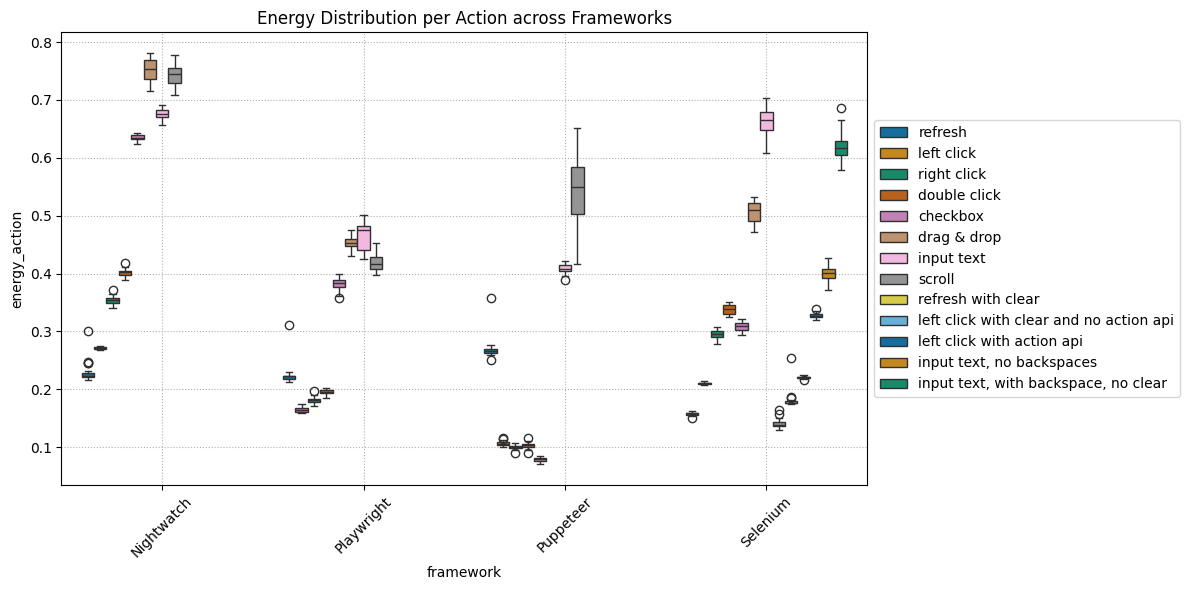

In [8]:
# Visualize the distribution of energy by framework and action category
plt.figure(figsize=(12, 6))
sns.boxplot(data=energy_df, x="framework", y="energy_action", hue="action_category",palette="colorblind",legend=True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45)
plt.title("Energy Distribution per Action across Frameworks")
plt.grid(True, linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.show()


# isolate cross-cutting actions
Create a dataframe for the actions:
- 'checkbox',
- 'double click',
- 'drag & drop',
- 'input text',
- 'left click',
- 'refresh',
- 'right click',
- 'scroll'
  
and evaluate normality for those

In [9]:
# Filter the dataset to include only the specified actions
selected_actions = [
    'checkbox',
    'double click',
    'drag & drop',
    'input text',
    'left click',
    'refresh',
    'right click',
    'scroll'
]

selected_energy_df = energy_df[energy_df['action_category'].isin(selected_actions)].copy()


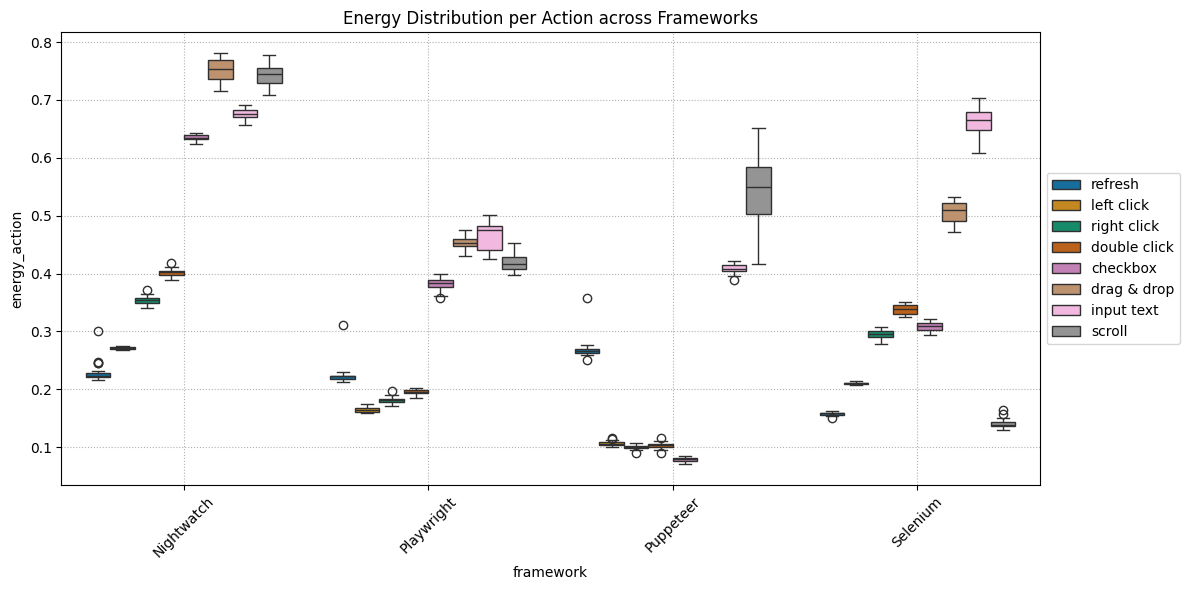

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=selected_energy_df, x="framework", y="energy_action", hue="action_category",palette="colorblind",legend=True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45)
plt.title("Energy Distribution per Action across Frameworks")
plt.grid(True, linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.savefig('figures/energy-distribution-per-action-across-frameworks.png')
plt.show()

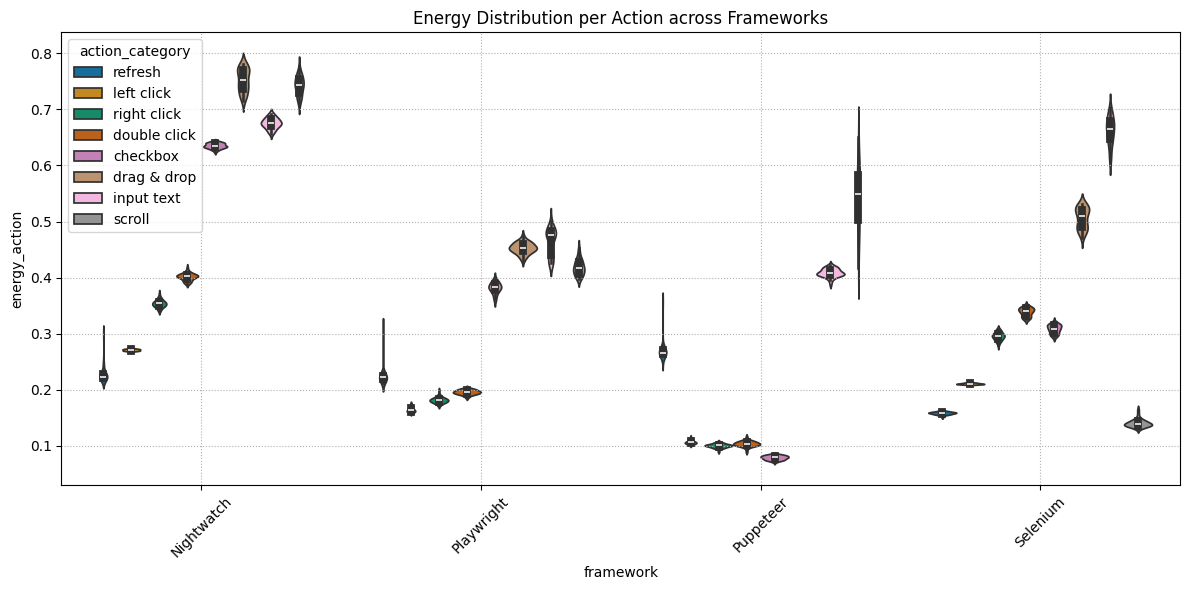

In [11]:
# Visualize the distribution of energy by framework and action category
plt.figure(figsize=(12, 6))
sns.violinplot(data=selected_energy_df, x="framework", y="energy_action", hue="action_category",palette="colorblind")
plt.xticks(rotation=45)
plt.title("Energy Distribution per Action across Frameworks")
plt.grid(True, linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.savefig('figures/energy-distribution-per-action-across-frameworks-violin.png')
plt.show()

<Figure size 1200x600 with 0 Axes>

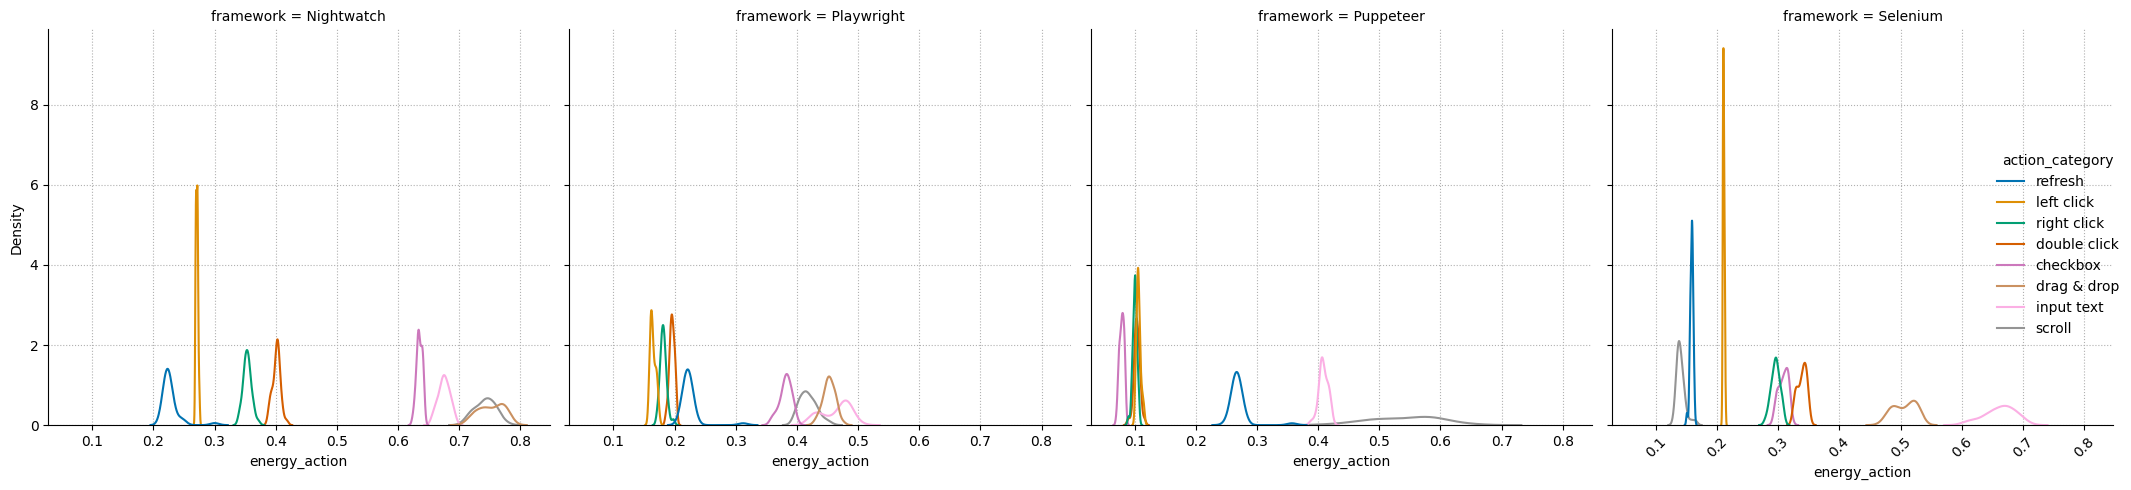

In [12]:
# Visualize the distribution of energy by framework and action category
huecat = selected_energy_df['framework'].astype(str) + ', ' + selected_energy_df['action_category'].astype(str)
plt.figure(figsize=(12, 6))
g = sns.displot(data=selected_energy_df, x="energy_action",  hue='action_category', col="framework", palette="colorblind", kind="kde")
for ax in g.axes.flat:
    ax.grid(True, linestyle=':', linewidth=0.8)
plt.xticks(rotation=45)
#plt.title("Energy Distribution per Action across Frameworks")
plt.tight_layout()
plt.savefig('figures/action-distributions.png')
plt.show()




<Figure size 1200x600 with 0 Axes>

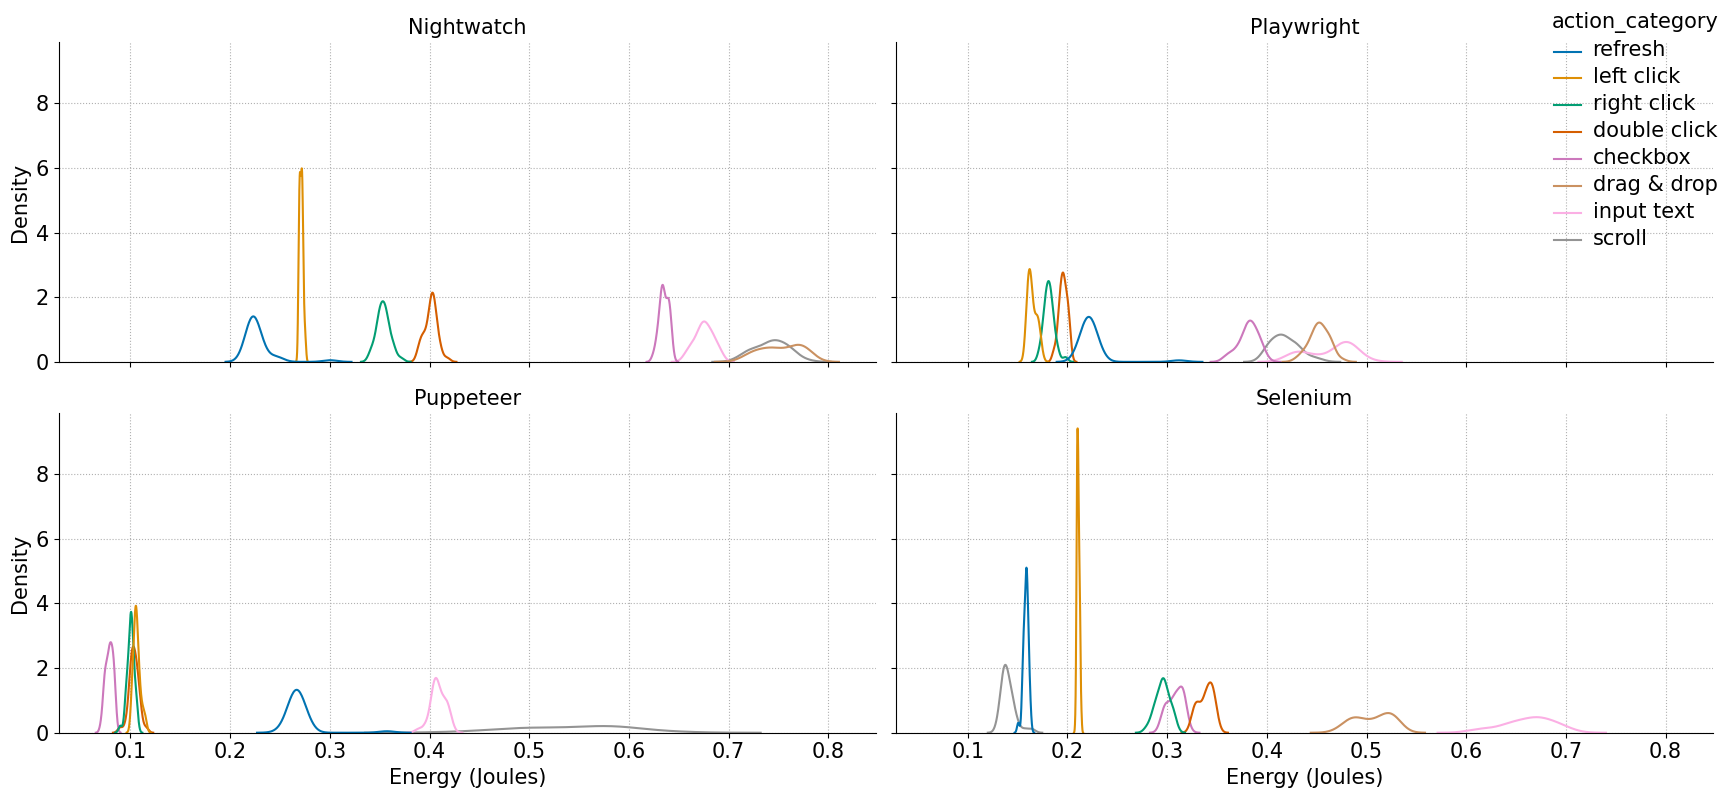

In [71]:
# Visualize the distribution of energy by framework and action category
huecat = selected_energy_df['framework'].astype(str) + ', ' + selected_energy_df['action_category'].astype(str)
plt.figure(figsize=(12, 6))
g = sns.displot(data=selected_energy_df, 
    x="energy_action",  
    hue='action_category', 
    col="framework", 
    palette="colorblind", 
    kind="kde",
    col_wrap=2,
    height=4, aspect=2,

)
for ax in g.axes.flat:
    ax.grid(True, linestyle=':', linewidth=0.8)
    ax.tick_params(axis='both', labelsize=15)
    ax.xaxis.label.set_size(15)
    ax.yaxis.label.set_size(15)
#plt.xticks(rotation=45)

for title in g.axes_dict:
    g.axes_dict[title].set_title(title, fontsize=15)


sns.move_legend(g, "upper right")

# Legend title
g.legend.get_title().set_fontsize(15)
# Legend texts
for text in g.legend.texts:
    text.set_fontsize(15)
   



g.set_axis_labels("Energy (Joules)", "Density")
#plt.title("Energy Distribution per Action across Frameworks")
plt.tight_layout()
plt.savefig('figures/action-distributions_2x2.png')
plt.show()



In [14]:
from scipy.stats import shapiro, anderson

# Prepare new DataFrames for results
shapiro_results = []
anderson_results = []

# Group the filtered data by (framework, action) for normality testing
grouped = selected_energy_df.groupby(['framework', 'action_category'])

for (framework, action), group in grouped:
    data = group['energy_action']
    if len(data) >= 3:
        # Shapiro-Wilk
        shapiro_stat, shapiro_p = shapiro(data)
        shapiro_results.append({
            'framework': framework,
            'action': action,
            'n': len(data),
            'shapiro_W': shapiro_stat,
            'shapiro_p': shapiro_p,
            'shapiro_normal': shapiro_p > 0.05
        })

        # Anderson-Darling
        ad_result = anderson(data, dist='norm')
        critical_val = ad_result.critical_values[2]  # 5% significance
        ad_stat = ad_result.statistic
        anderson_results.append({
            'framework': framework,
            'action': action,
            'n': len(data),
            'anderson_A2': ad_stat,
            'anderson_crit_5pct': critical_val,
            'anderson_normal': ad_stat < critical_val
        })

# Convert to DataFrames
shapiro_df = pd.DataFrame(shapiro_results)
anderson_df = pd.DataFrame(anderson_results)

# Merge both test results into one DataFrame
normality_combined_df = pd.merge(
    shapiro_df[['framework', 'action', 'shapiro_normal']],
    anderson_df[['framework', 'action', 'anderson_normal']],
    on=['framework', 'action']
)


/var/folders/jz/ddk9k2995g78dvz3jlrl6n_h0000gn/T/ipykernel_26790/4160765884.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shapiro_map = normality_combined_df.pivot(index='action', columns='framework', values='shapiro_normal').fillna(False).astype(int)
/var/folders/jz/ddk9k2995g78dvz3jlrl6n_h0000gn/T/ipykernel_26790/4160765884.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  anderson_map = normality_combined_df.pivot(index='action', columns='framework', values='anderson_normal').fillna(False).astype(int)


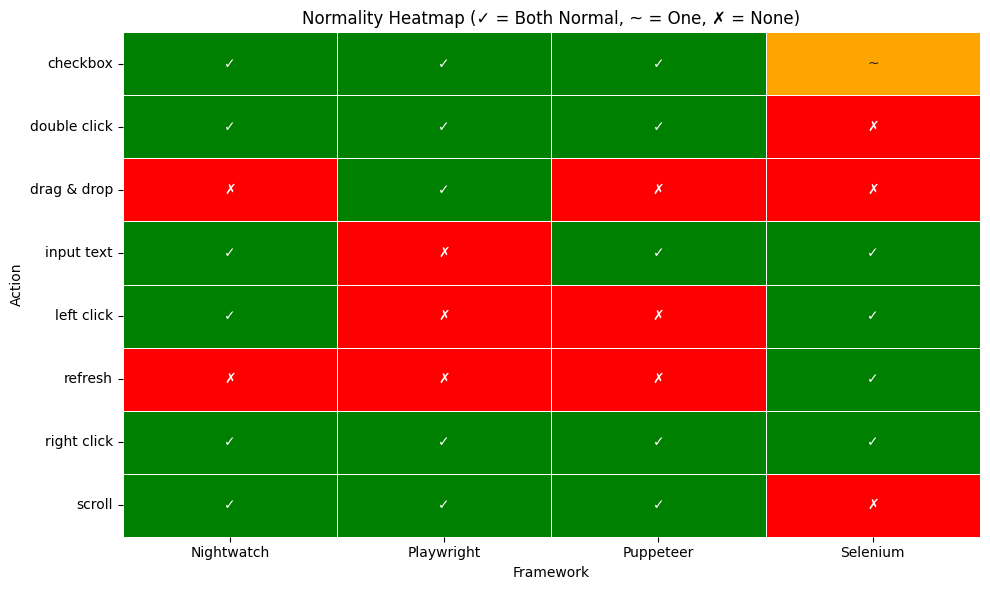

In [15]:
# Fix potential NaNs before converting to int
shapiro_map = normality_combined_df.pivot(index='action', columns='framework', values='shapiro_normal').fillna(False).astype(int)
anderson_map = normality_combined_df.pivot(index='action', columns='framework', values='anderson_normal').fillna(False).astype(int)
combined_map = shapiro_map + anderson_map  # 0 = none, 1 = one, 2 = both

# Create symbolic labels
plot_labels = combined_map.replace({
    2: "✓",    # Both normal
    1: "~",    # One normal
    0: "✗"     # None normal
})

# Define color map
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["red", "orange", "green"])  # 0 = red, 1 = orange, 2 = green

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(combined_map, annot=plot_labels, fmt="", cmap=cmap, cbar=False, linewidths=.5)
plt.title("Normality Heatmap (✓ = Both Normal, ~ = One, ✗ = None)")
plt.ylabel("Action")
plt.xlabel("Framework")
plt.tight_layout()
#plt.savefig('figures/normality-heatmap.png')
plt.show()


/var/folders/jz/ddk9k2995g78dvz3jlrl6n_h0000gn/T/ipykernel_26790/2926541295.py:15: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((col, row), 1, 1, fill=True, color="lightgray", edgecolor="black", linewidth=0.5))


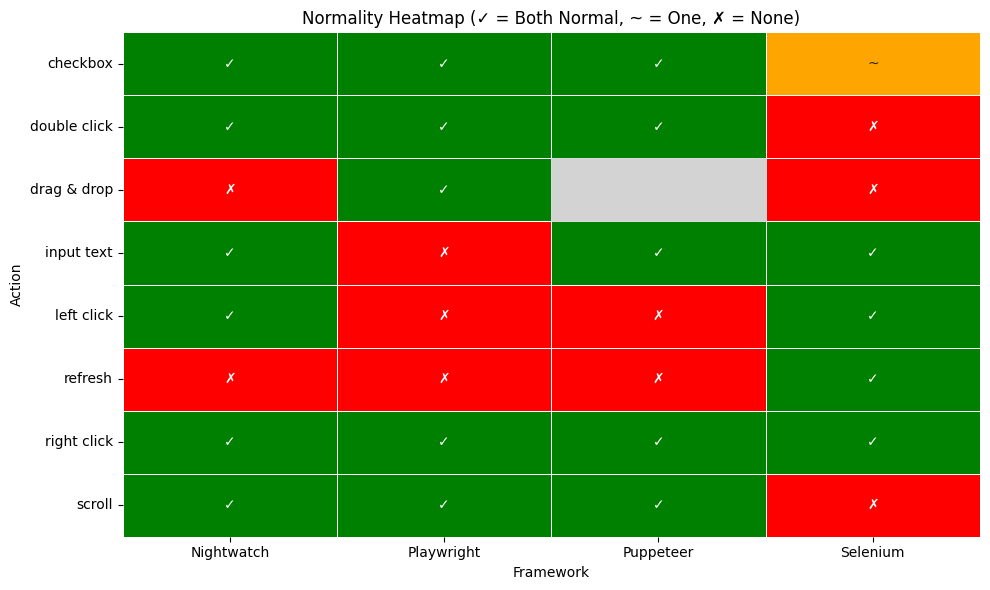

In [16]:

import numpy as np

# Create a mask for the cell you want to gray out
mask = np.zeros_like(combined_map, dtype=bool)
mask[combined_map.index.get_loc("drag & drop"), combined_map.columns.get_loc("Puppeteer")] = True

# Plot heatmap with mask
plt.figure(figsize=(10, 6))
sns.heatmap(combined_map, annot=plot_labels, fmt="", cmap=cmap, cbar=False, linewidths=.5, mask=mask)

# Overlay gray rectangle for the masked cell
ax = plt.gca()
row = combined_map.index.get_loc("drag & drop")
col = combined_map.columns.get_loc("Puppeteer")
ax.add_patch(plt.Rectangle((col, row), 1, 1, fill=True, color="lightgray", edgecolor="black", linewidth=0.5))

plt.title("Normality Heatmap (✓ = Both Normal, ~ = One, ✗ = None)")
plt.ylabel("Action")
plt.xlabel("Framework")
plt.tight_layout()
plt.savefig('figures/normality-heatmap.png')
plt.show()


In [17]:
# RQ 1

/var/folders/jz/ddk9k2995g78dvz3jlrl6n_h0000gn/T/ipykernel_26790/1504337748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=selected_energy_df, x="action_category", y="energy", palette="colorblind")


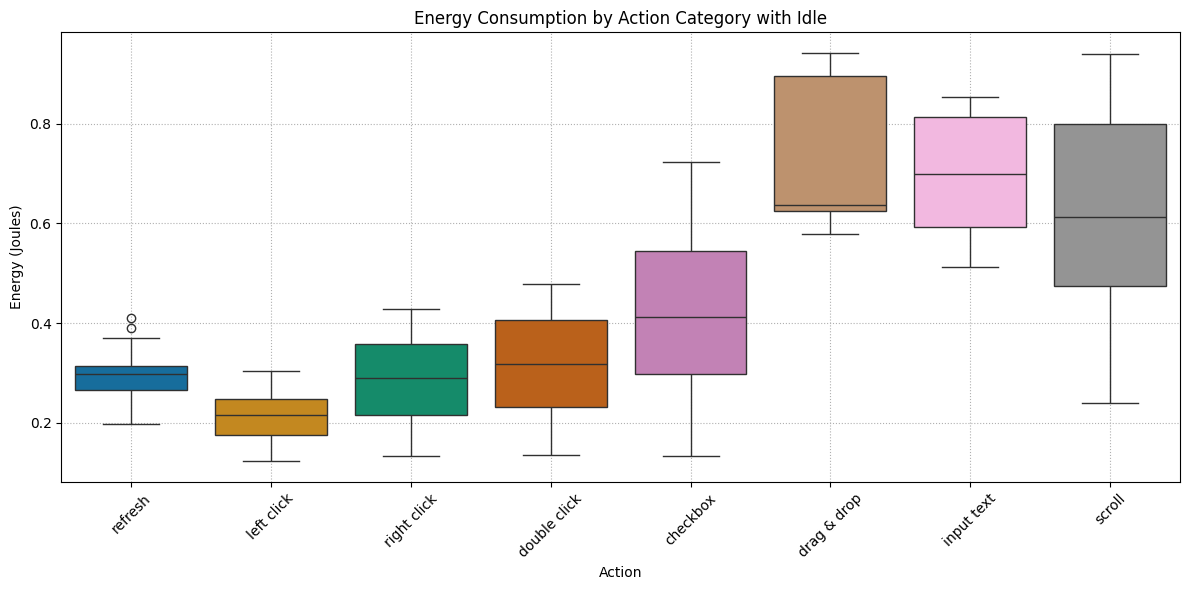

In [18]:
# Create a boxplot of energy consumption by action category (across all frameworks)
plt.figure(figsize=(12, 6))
sns.boxplot(data=selected_energy_df, x="action_category", y="energy", palette="colorblind")
plt.title("Energy Consumption by Action Category with Idle")
plt.xlabel("Action")
plt.ylabel("Energy (Joules)")
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.savefig('figures/RQ1-boxplot_idle.png')
plt.show()

/var/folders/jz/ddk9k2995g78dvz3jlrl6n_h0000gn/T/ipykernel_26790/664171789.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=selected_energy_df, x="action_category", y="energy_action", palette="colorblind")


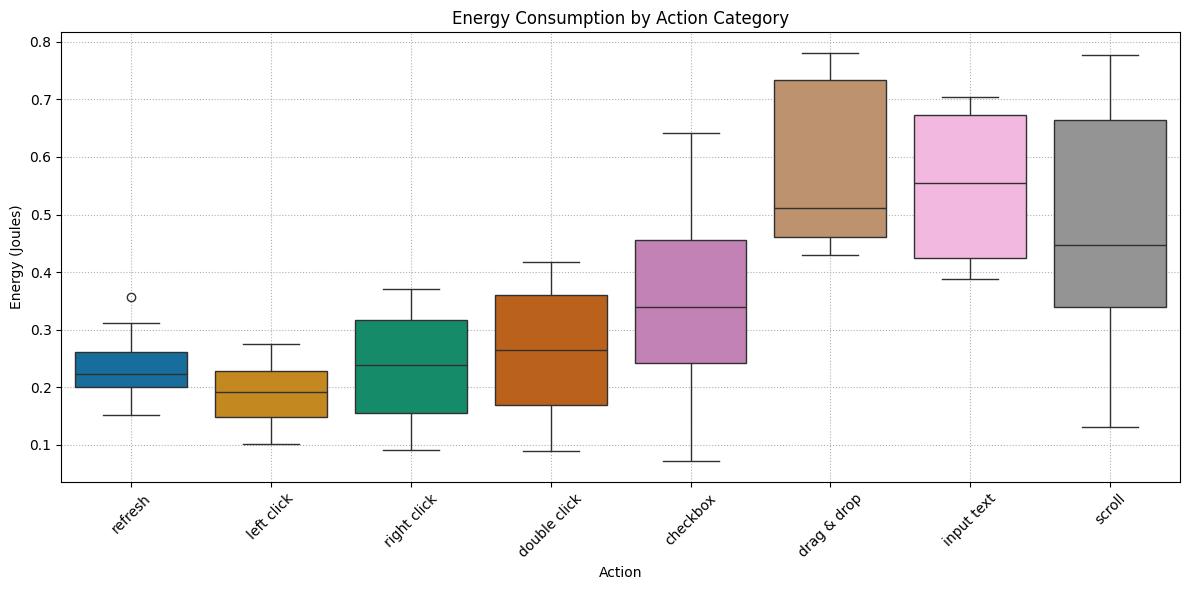

In [19]:
# Create a boxplot of energy consumption by action category (across all frameworks)
plt.figure(figsize=(12, 6))
sns.boxplot(data=selected_energy_df, x="action_category", y="energy_action", palette="colorblind")
plt.title("Energy Consumption by Action Category")
plt.xlabel("Action")
plt.ylabel("Energy (Joules)")
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.savefig('figures/RQ1-boxplot.png')
plt.show()

In [20]:
# For RQ1: Does energy consumption differ between action categories across all frameworks?
# Using the previously filtered dataset with 8 shared actions

from scipy.stats import kruskal

# Group energy values by action_category
rq1_groups = [
    group['energy_action'] for name, group in selected_energy_df.groupby('action_category') if len(group) > 2
]

# Run Kruskal-Wallis test
rq1_stat, rq1_p = kruskal(*rq1_groups)

# Report the result
{
    "RQ1 Kruskal-Wallis H-statistic": rq1_stat,
    "p-value": rq1_p,
    "Significant? (alpha = 0.05)": rq1_p < 0.05
}


{'RQ1 Kruskal-Wallis H-statistic': np.float64(552.4485984897049),
 'p-value': np.float64(4.19588624967834e-115),
 'Significant? (alpha = 0.05)': np.True_}

In [21]:
# !pip install scikit-posthocs
# pip install Jinja2

In [22]:

import scikit_posthocs as sp
import numpy as np

# Prepare data for Dunn's test
data = selected_energy_df[['action_category', 'energy_action']]

# Apply Dunn's test with Bonferroni correction
dunn_result = sp.posthoc_dunn(data, val_col='energy_action', group_col='action_category', p_adjust='bonferroni')

# Display
display(dunn_result)
dunn_result.to_latex()

,checkbox,double click,drag & drop,input text,left click,refresh,right click,scroll
checkbox,1.000000e+00,4.083745e-02,7.559898e-19,3.956791e-18,5.210024e-10,4.958569e-05,1.290182e-04,1.198152e-04
double click,4.083745e-02,1.000000e+00,1.154473e-32,5.722619e-33,1.147255e-02,1.000000e+00,1.000000e+00,2.028053e-13
drag & drop,7.559898e-19,1.154473e-32,1.000000e+00,1.000000e+00,2.159716e-52,5.367300e-41,6.377717e-40,1.836971e-05
input text,3.956791e-18,5.722619e-33,1.000000e+00,1.000000e+00,1.450492e-54,4.755834e-42,7.120430e-41,2.360785e-04
left click,5.210024e-10,1.147255e-02,2.159716e-52,1.450492e-54,1.000000e+00,1.000000e+00,9.180905e-01,3.136026e-28
refresh,4.958569e-05,1.000000e+00,5.367300e-41,4.755834e-42,1.000000e+00,1.000000e+00,1.000000e+00,1.931542e-19
right click,1.290182e-04,1.000000e+00,6.377717e-40,7.120430e-41,9.180905e-01,1.000000e+00,1.000000e+00,1.215608e-18
scroll,1.198152e-04,2.028053e-13,1.836971e-05,2.360785e-04,3.136026e-28,1.931542e-19,1.215608e-18,1.000000e+00


'\\begin{tabular}{lrrrrrrrr}\n\\toprule\n & checkbox & double click & drag & drop & input text & left click & refresh & right click & scroll \\\\\n\\midrule\ncheckbox & 1.000000 & 0.040837 & 0.000000 & 0.000000 & 0.000000 & 0.000050 & 0.000129 & 0.000120 \\\\\ndouble click & 0.040837 & 1.000000 & 0.000000 & 0.000000 & 0.011473 & 1.000000 & 1.000000 & 0.000000 \\\\\ndrag & drop & 0.000000 & 0.000000 & 1.000000 & 1.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000018 \\\\\ninput text & 0.000000 & 0.000000 & 1.000000 & 1.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000236 \\\\\nleft click & 0.000000 & 0.011473 & 0.000000 & 0.000000 & 1.000000 & 1.000000 & 0.918090 & 0.000000 \\\\\nrefresh & 0.000050 & 1.000000 & 0.000000 & 0.000000 & 1.000000 & 1.000000 & 1.000000 & 0.000000 \\\\\nright click & 0.000129 & 1.000000 & 0.000000 & 0.000000 & 0.918090 & 1.000000 & 1.000000 & 0.000000 \\\\\nscroll & 0.000120 & 0.000000 & 0.000018 & 0.000236 & 0.000000 & 0.000000 & 0.000000 & 1.000000 \\\\\n\\botto

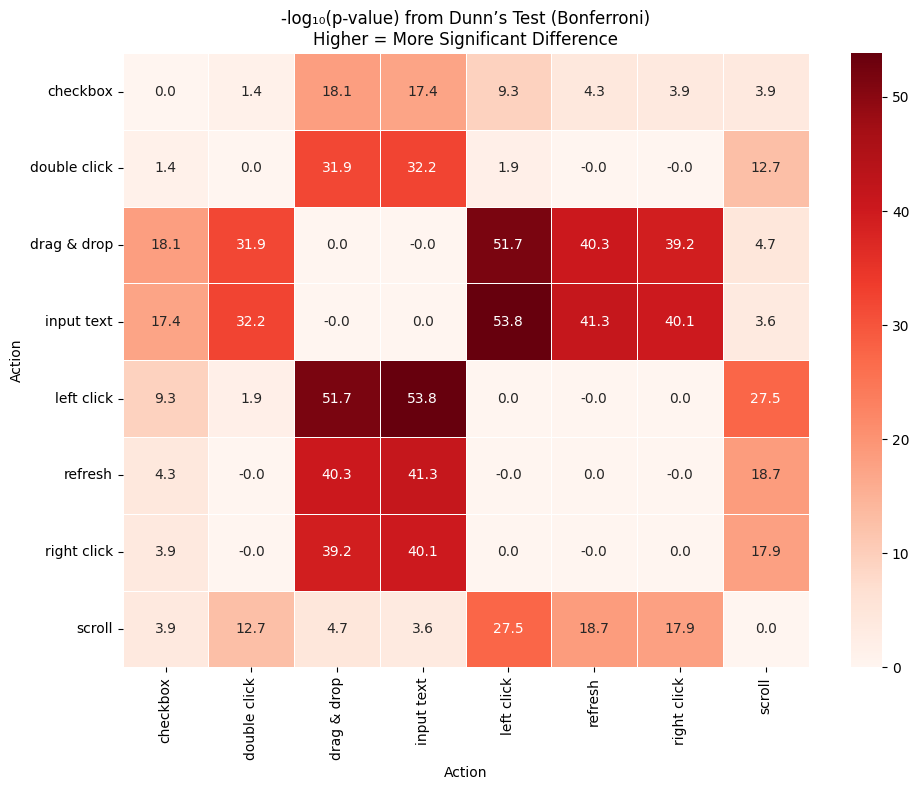

In [23]:

# Apply transformation
dunn_visual = -np.log10(dunn_result)
dunn_visual.replace([np.inf, -np.inf], np.nan, inplace=True)
np.fill_diagonal(dunn_visual.values, 0)  # Set diagonal to 0 for clarity

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(dunn_visual, cmap="Reds", annot=True, fmt=".1f", linewidths=.5)
plt.title("-log₁₀(p-value) from Dunn’s Test (Bonferroni)\nHigher = More Significant Difference")
plt.ylabel("Action")
plt.xlabel("Action")
plt.tight_layout()
plt.savefig('figures/RQ1-dunns-bonferroni.png')
plt.show()

In [24]:
import numpy as np

#mean values:

energy_data = selected_energy_df[['action_category', 'energy_action']]
energy_idle_data = selected_energy_df[['action_category', 'energy']]
time_pr_data = selected_energy_df[['action_category', 'time_pr_run']]
time_data = selected_energy_df[['action_category', 'time']]

#df.groupby(['team'], as_index=False).agg({'points':['mean','std']})

energy_data_all_frameworks = selected_energy_df.groupby(['action_category'], as_index=False).agg({'energy_action':['mean', 'std']})
energy_idle_data_all_frameworks = selected_energy_df.groupby(['action_category'], as_index=False).agg({'energy':['mean', 'std']})
time_pr_data_all_frameworks = selected_energy_df.groupby(['action_category'], as_index=False).agg({'time_pr_run':['mean', 'std']})
time_data_all_frameworks = selected_energy_df.groupby(['action_category'], as_index=False).agg({'time':['mean', 'std']})

display(energy_data_all_frameworks)
display(energy_idle_data_all_frameworks)
display(time_pr_data_all_frameworks)
display(time_data_all_frameworks)

energy_data_pr_frameworks = selected_energy_df.groupby(['framework','action_category'], as_index=False).agg({'energy_action':['mean', 'std']})
energy_idle_data_pr_frameworks = selected_energy_df.groupby(['framework','action_category'], as_index=False).agg({'energy':['mean', 'std']})
time_pr_data_pr_frameworks = selected_energy_df.groupby(['framework','action_category'], as_index=False).agg({'time_pr_run':['mean', 'std']})
time_data_pr_frameworks = selected_energy_df.groupby(['framework','action_category'], as_index=False).agg({'time':['mean', 'std']})

energy_data_pr_frameworks = selected_energy_df.groupby(['action_category','framework'], as_index=False).agg({'energy_action':['mean', 'std']})
energy_idle_data_pr_frameworks = selected_energy_df.groupby(['action_category','framework'], as_index=False).agg({'energy':['mean', 'std']})
time_pr_data_pr_frameworks = selected_energy_df.groupby(['action_category','framework'], as_index=False).agg({'time_pr_run':['mean', 'std']})
time_data_pr_frameworks = selected_energy_df.groupby(['action_category','framework'], as_index=False).agg({'time':['mean', 'std']})

display(energy_data_pr_frameworks)
display(energy_idle_data_pr_frameworks)
display(time_pr_data_pr_frameworks)
display(time_data_pr_frameworks)





action_category energy_action          
                           mean       std
0        checkbox      0.351009  0.199367
1    double click      0.259808  0.117611
2     drag & drop      0.570598  0.132227
3      input text      0.552579  0.119776
4      left click      0.188276  0.060825
5         refresh      0.219782  0.042027
6     right click      0.232747  0.098951
7          scroll      0.461101  0.221107

action_category    energy          
                       mean       std
0        checkbox  0.423107  0.207808
1    double click  0.313882  0.118280
2     drag & drop  0.721249  0.138113
3      input text  0.696775  0.118278
4      left click  0.212995  0.061946
5         refresh  0.281580  0.047456
6     right click  0.283640  0.099886
7          scroll  0.605297  0.237284

action_category   time_pr_run             
                           mean          std
0        checkbox  18212.950000  8197.769021
1    double click  19880.221429  8695.838318
2     drag & drop  17529.914286  3680.023179
3      input text  14354.242857  2648.144766
4      left click  25210.114286  6662.115293
5         refresh  12610.614286  1918.967707
6     right click  19609.814286  8374.744056
7          scroll  13838.978571  5981.965248

action_category        time           
                         mean        std
0        checkbox  151.774583  68.314742
1    double click  124.251384  54.348989
2     drag & drop  292.165238  61.333720
3      input text  239.237381  44.135746
4      left click   72.028898  19.034615
5         refresh   90.075816  13.706912
6     right click  115.351849  49.263200
7          scroll  230.649643  99.699421

action_category   framework energy_action          
                                        mean       std
0         checkbox  Nightwatch      0.635310  0.004624
1         checkbox  Playwright      0.381594  0.009789
2         checkbox   Puppeteer      0.078829  0.003739
3         checkbox    Selenium      0.308302  0.007664
4     double click  Nightwatch      0.401429  0.006320
5     double click  Playwright      0.195733  0.004102
6     double click   Puppeteer      0.103489  0.004822
7     double click    Selenium      0.338582  0.007390
8      drag & drop  Nightwatch      0.752642  0.020025
9      drag & drop  Playwright      0.452795  0.009775
10     drag & drop    Selenium      0.506357  0.018295
11      input text  Nightwatch      0.675464  0.009258
12      input text  Playwright      0.463856  0.023214
13      input text   Puppeteer      0.408667  0.007411
14      input text    Selenium      0.662330  0.024573
15      left click  Nightwatch      0.271283  0.001743
16      left click  Playwright      0.164669  0.004407
17      left click   Puppeteer      0.106391  0.003449
18      left click    Selenium      0.210760  0.001243
19         refresh  Nightwatch      0.227583  0.014626
20         refresh  Playwright      0.223997  0.015912
21         refresh   Puppeteer      0.269225  0.016179
22         refresh    Selenium      0.158321  0.002466
23     right click  Nightwatch      0.353702  0.006634
24     right click  Playwright      0.181570  0.005194
25     right click   Puppeteer      0.100204  0.003530
26     right click    Selenium      0.295512  0.007049
27          scroll  Nightwatch      0.742750  0.016736
28          scroll  Playwright      0.418408  0.013759
29          scroll   Puppeteer      0.542847  0.055309
30          scroll    Selenium      0.140398  0.006962

action_category   framework    energy          
                                    mean       std
0         checkbox  Nightwatch  0.715939  0.004624
1         checkbox  Playwright  0.472669  0.009789
2         checkbox   Puppeteer  0.141245  0.003739
3         checkbox    Selenium  0.362574  0.007664
4     double click  Nightwatch  0.461901  0.006320
5     double click  Playwright  0.264039  0.004102
6     double click   Puppeteer  0.150301  0.004822
7     double click    Selenium  0.379286  0.007390
8      drag & drop  Nightwatch  0.913900  0.020025
9      drag & drop  Playwright  0.634945  0.009775
10     drag & drop    Selenium  0.614901  0.018295
11      input text  Nightwatch  0.836722  0.009258
12      input text  Playwright  0.646006  0.023214
13      input text   Puppeteer  0.533498  0.007411
14      input text    Selenium  0.770874  0.024573
15      left click  Nightwatch  0.298927  0.001743
16      left click  Playwright  0.195895  0.004407
17      left click   Puppeteer  0.127791  0.003449
18      left click    Selenium  0.229368  0.001243
19         refresh  Nightwatch  0.296693  0.014626
20         refresh  Playwright  0.302061  0.015912
21         refresh   Puppeteer  0.322725  0.016179
22         refresh    Selenium  0.204840  0.002466
23     right click  Nightwatch  0.410617  0.006634
24     right click  Playwright  0.245859  0.005194
25     right click   Puppeteer  0.144263  0.003530
26     right click    Selenium  0.333821  0.007049
27          scroll  Nightwatch  0.904008  0.016736
28          scroll  Playwright  0.600558  0.013759
29          scroll   Puppeteer  0.667678  0.055309
30          scroll    Selenium  0.248942  0.006962

action_category   framework   time_pr_run             
                                        mean          std
0         checkbox  Nightwatch  28787.228571   103.124164
1         checkbox  Playwright  19083.171429   130.827341
2         checkbox   Puppeteer   5837.628571   156.879138
3         checkbox    Selenium  19143.771429   512.390768
4     double click  Nightwatch  30057.628571   310.517318
5     double click  Playwright  14472.342857    80.237494
6     double click   Puppeteer   8666.657143   113.105870
7     double click    Selenium  26324.257143   325.903571
8      drag & drop  Nightwatch  22198.485714   427.875695
9      drag & drop  Playwright  13291.200000    59.181078
10     drag & drop    Selenium  17100.057143   340.302283
11      input text  Nightwatch  16710.771429    75.815987
12      input text  Playwright  13032.228571    74.769090
13      input text   Puppeteer  10675.142857    71.308007
14      input text    Selenium  16998.828571    62.606843
15      left click  Nightwatch  34416.742857   124.080226
16      left click  Playwright  23956.400000    80.169746
17      left click   Puppeteer  15836.885714   170.533897
18      left click    Selenium  26630.428571    96.501840
19         refresh  Nightwatch  13949.685714   621.746769
20         refresh  Playwright  13478.857143   898.910522
21         refresh   Puppeteer  13455.600000   951.847899
22         refresh    Selenium   9558.314286    81.395104
23     right click  Nightwatch  29364.885714   542.723783
24     right click  Playwright  14830.571429    73.748095
25     right click   Puppeteer   8534.114286    85.742011
26     right click    Selenium  25709.685714   609.397956
27          scroll  Nightwatch  21955.942857   499.823966
28          scroll  Playwright  12340.171429    65.088847
29          scroll   Puppeteer  15521.885714  1431.445028
30          scroll    Selenium   5537.914286    68.558850

action_category   framework        time           
                                      mean        std
0         checkbox  Nightwatch  239.893571   0.859368
1         checkbox  Playwright  159.026429   1.090228
2         checkbox   Puppeteer   48.646905   1.307326
3         checkbox    Selenium  159.531429   4.269923
4     double click  Nightwatch  187.860179   1.940733
5     double click  Playwright   90.452143   0.501484
6     double click   Puppeteer   54.166607   0.706912
7     double click    Selenium  164.526607   2.036897
8      drag & drop  Nightwatch  369.974762   7.131262
9      drag & drop  Playwright  221.520000   0.986351
10     drag & drop    Selenium  285.000952   5.671705
11      input text  Nightwatch  278.512857   1.263600
12      input text  Playwright  217.203810   1.246151
13      input text   Puppeteer  177.919048   1.188467
14      input text    Selenium  283.313810   1.043447
15      left click  Nightwatch   98.333551   0.354515
16      left click  Playwright   68.446857   0.229056
17      left click   Puppeteer   45.248245   0.487240
18      left click    Selenium   76.086939   0.275720
19         refresh  Nightwatch   99.640612   4.441048
20         refresh  Playwright   96.277551   6.420789
21         refresh   Puppeteer   96.111429   6.798914
22         refresh    Selenium   68.273673   0.581394
23     right click  Nightwatch  172.734622   3.192493
24     right click  Playwright   87.238655   0.433812
25     right click   Puppeteer   50.200672   0.504365
26     right click    Selenium  151.233445   3.584694
27          scroll  Nightwatch  365.932381   8.330399
28          scroll  Playwright  205.669524   1.084814
29          scroll   Puppeteer  258.698095  23.857417
30          scroll    Selenium   92.298571   1.142648

In [25]:
#The unique combination of framework, action_category, energy_idle is showed
unique_idle_df = energy_df[['framework', 'action_category', 'energy_idle']].drop_duplicates()

unique_idle_df

,framework,action_category,energy_idle
0,Nightwatch,refresh,9.675489
35,Nightwatch,left click,9.675489
70,Nightwatch,right click,9.675489
105,Nightwatch,double click,9.675489
140,Nightwatch,checkbox,9.675489
175,Nightwatch,drag & drop,9.675489
210,Nightwatch,input text,9.675489
245,Nightwatch,scroll,9.675489
280,Playwright,refresh,10.929004
315,Playwright,left click,10.929004


In [26]:
# RQ2 

/var/folders/jz/ddk9k2995g78dvz3jlrl6n_h0000gn/T/ipykernel_26790/2393271039.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=selected_energy_df, x="framework", y="energy_action", palette="colorblind")


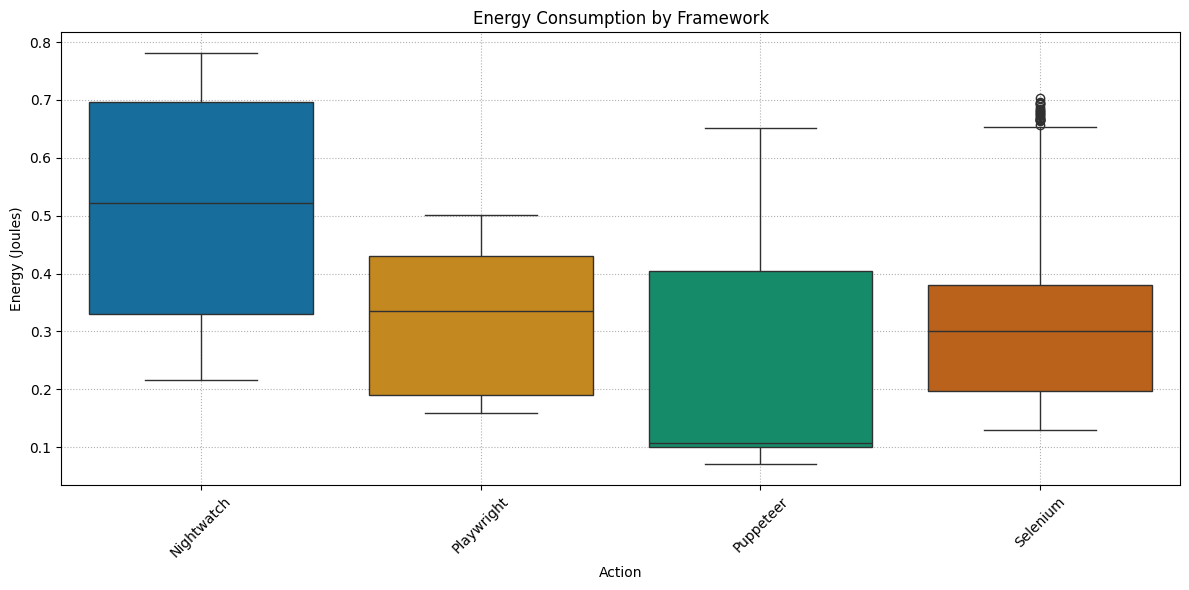

In [27]:
# Create a boxplot of energy consumption by action category (across all frameworks)
plt.figure(figsize=(12, 6))
sns.boxplot(data=selected_energy_df, x="framework", y="energy_action", palette="colorblind")
plt.title("Energy Consumption by Framework")
plt.xlabel("Action")
plt.ylabel("Energy (Joules)")
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.savefig('figures/RQ2-boxplot-framework.png')
plt.show()

/var/folders/jz/ddk9k2995g78dvz3jlrl6n_h0000gn/T/ipykernel_26790/3403685553.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=selected_energy_df, x="framework", y="energy_action", palette="colorblind")


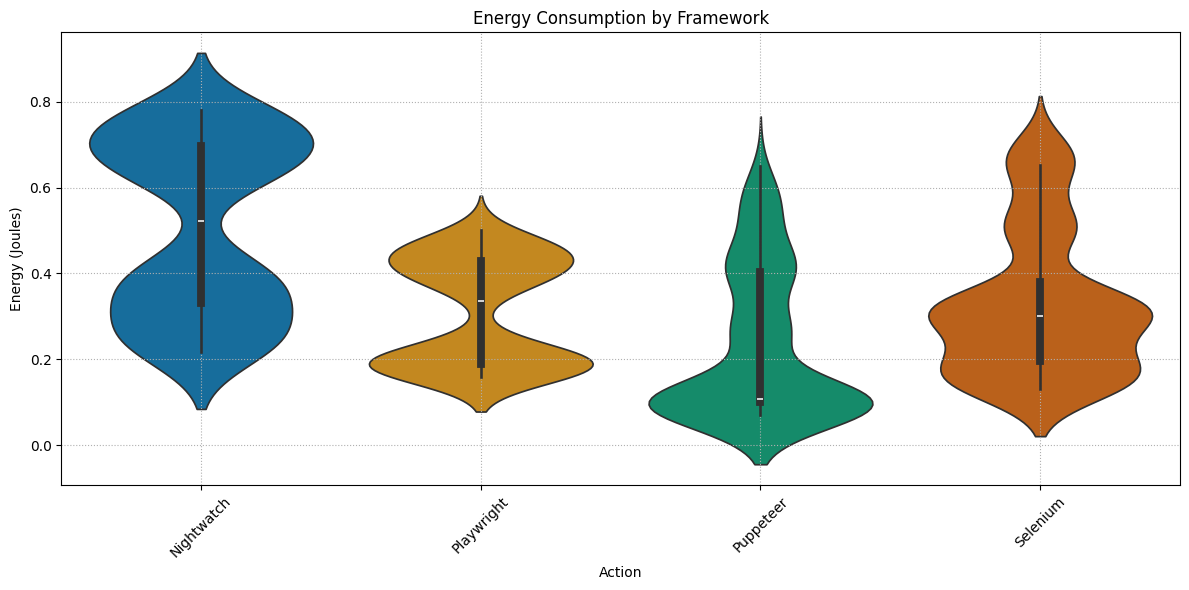

In [28]:
# Create a boxplot of energy consumption by action category (across all frameworks)
plt.figure(figsize=(12, 6))
sns.violinplot(data=selected_energy_df, x="framework", y="energy_action", palette="colorblind")
plt.title("Energy Consumption by Framework")
plt.xlabel("Action")
plt.ylabel("Energy (Joules)")
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.savefig('figures/RQ2-violinplot-framework.png')
plt.show()

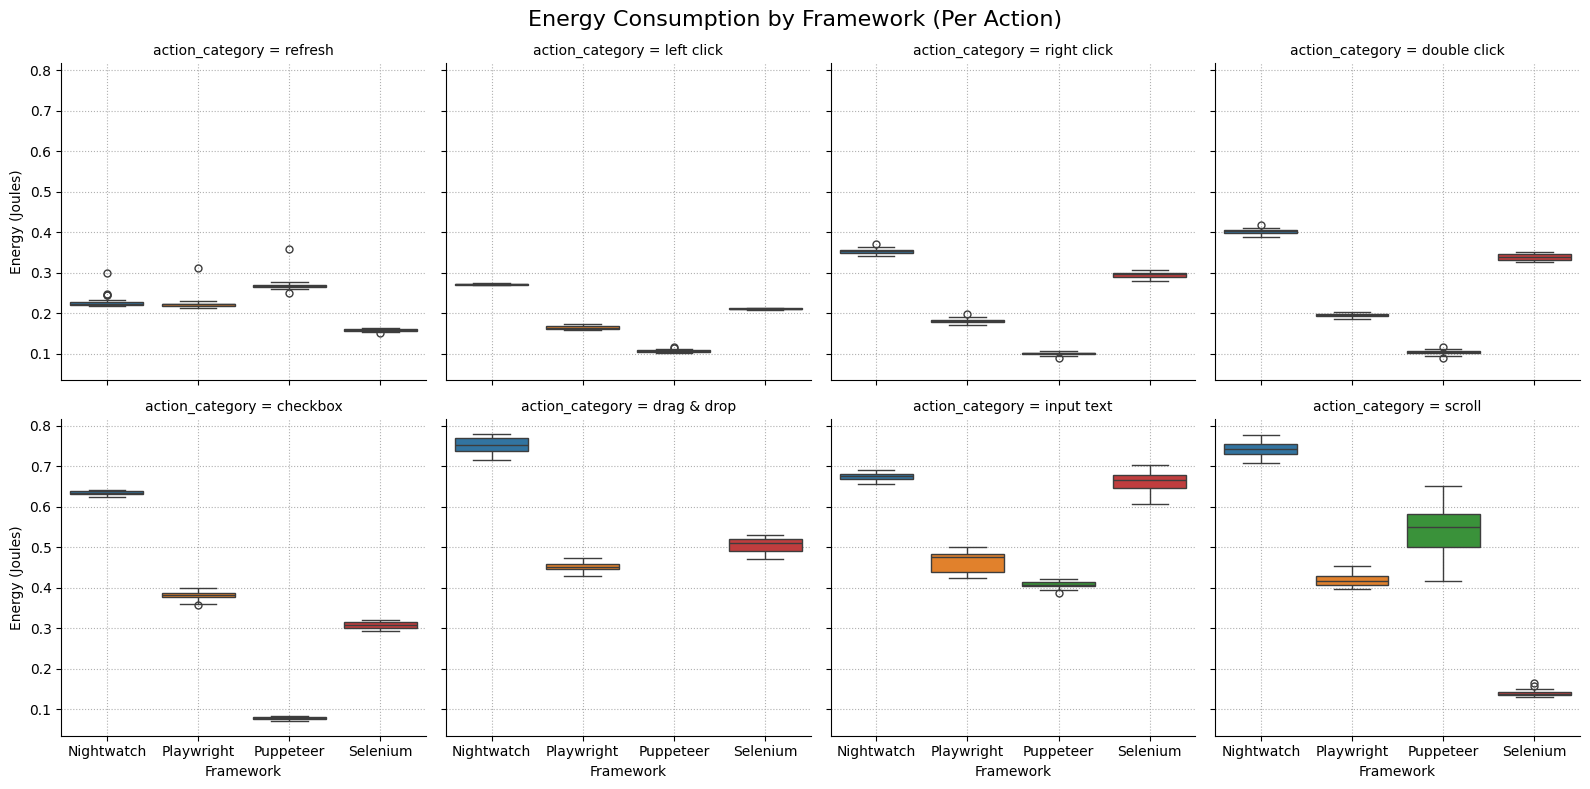

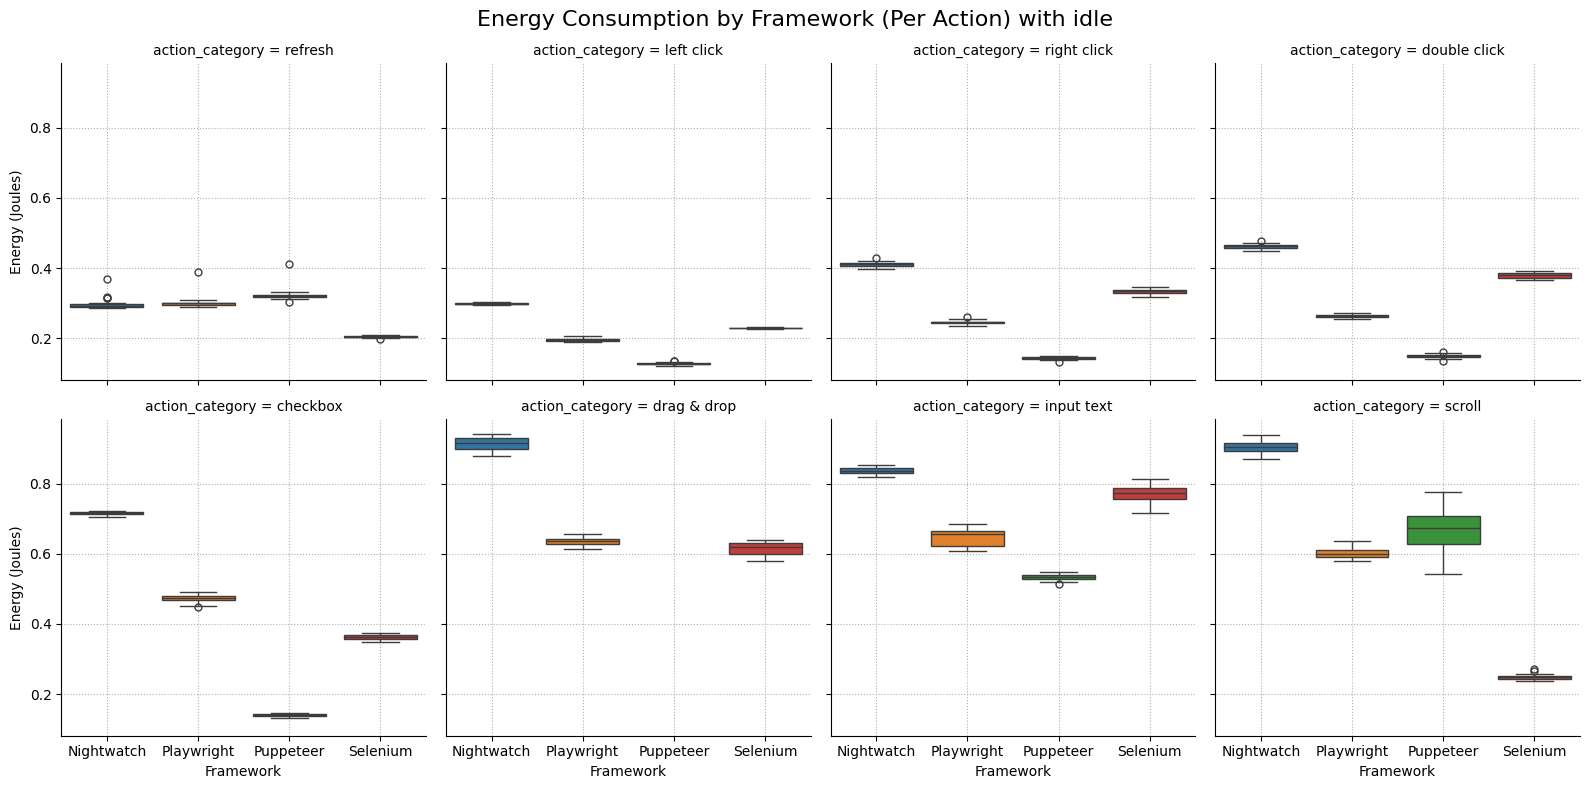

In [29]:
# Create a separate boxplot per action using FacetGrid
g = sns.catplot(
    data=selected_energy_df,
    x="framework", y="energy_action",
    col="action_category",
    kind="box",
    hue="framework",
    col_wrap=4,
    height=4, aspect=1,
)

for ax in g.axes.flat:
    ax.grid(True, linestyle=':', linewidth=0.8)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Energy Consumption by Framework (Per Action)", fontsize=16)
g.set_axis_labels("Framework", "Energy (Joules)")
plt.tight_layout()
plt.savefig('figures/RQ2-boxplot-action.png')
plt.show()

# Create a separate boxplot per action using FacetGrid
g = sns.catplot(
    data=selected_energy_df,
    x="framework", y="energy",
    col="action_category",
    kind="box",
    hue="framework",
    col_wrap=4,
    height=4, aspect=1
)

for ax in g.axes.flat:
    ax.grid(True, linestyle=':', linewidth=0.8)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Energy Consumption by Framework (Per Action) with idle", fontsize=16)
g.set_axis_labels("Framework", "Energy (Joules)")
plt.tight_layout()
plt.savefig('figures/RQ2-boxplot-action-with-idle.png')
plt.show()




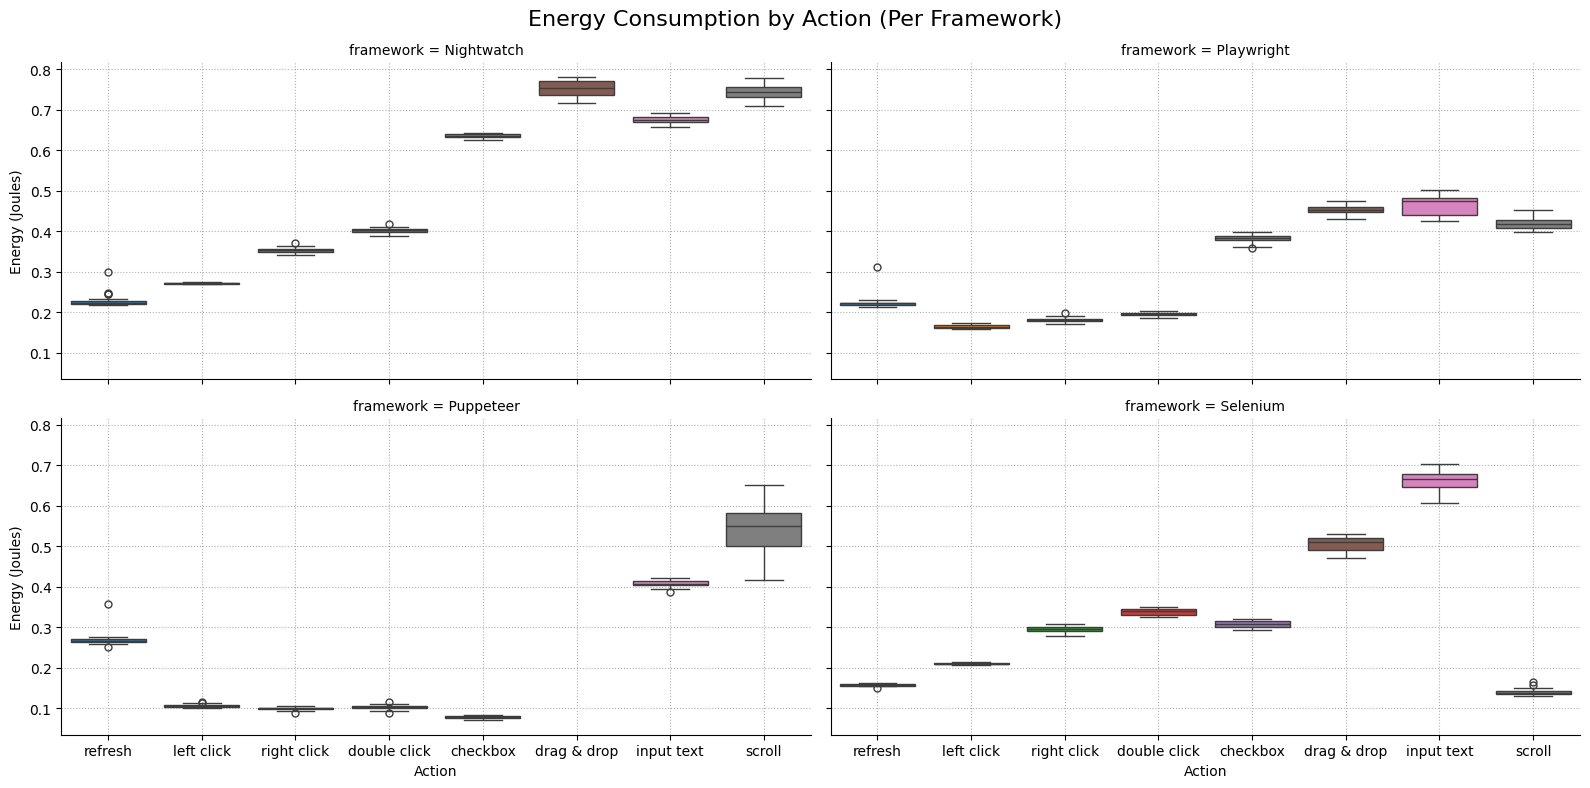

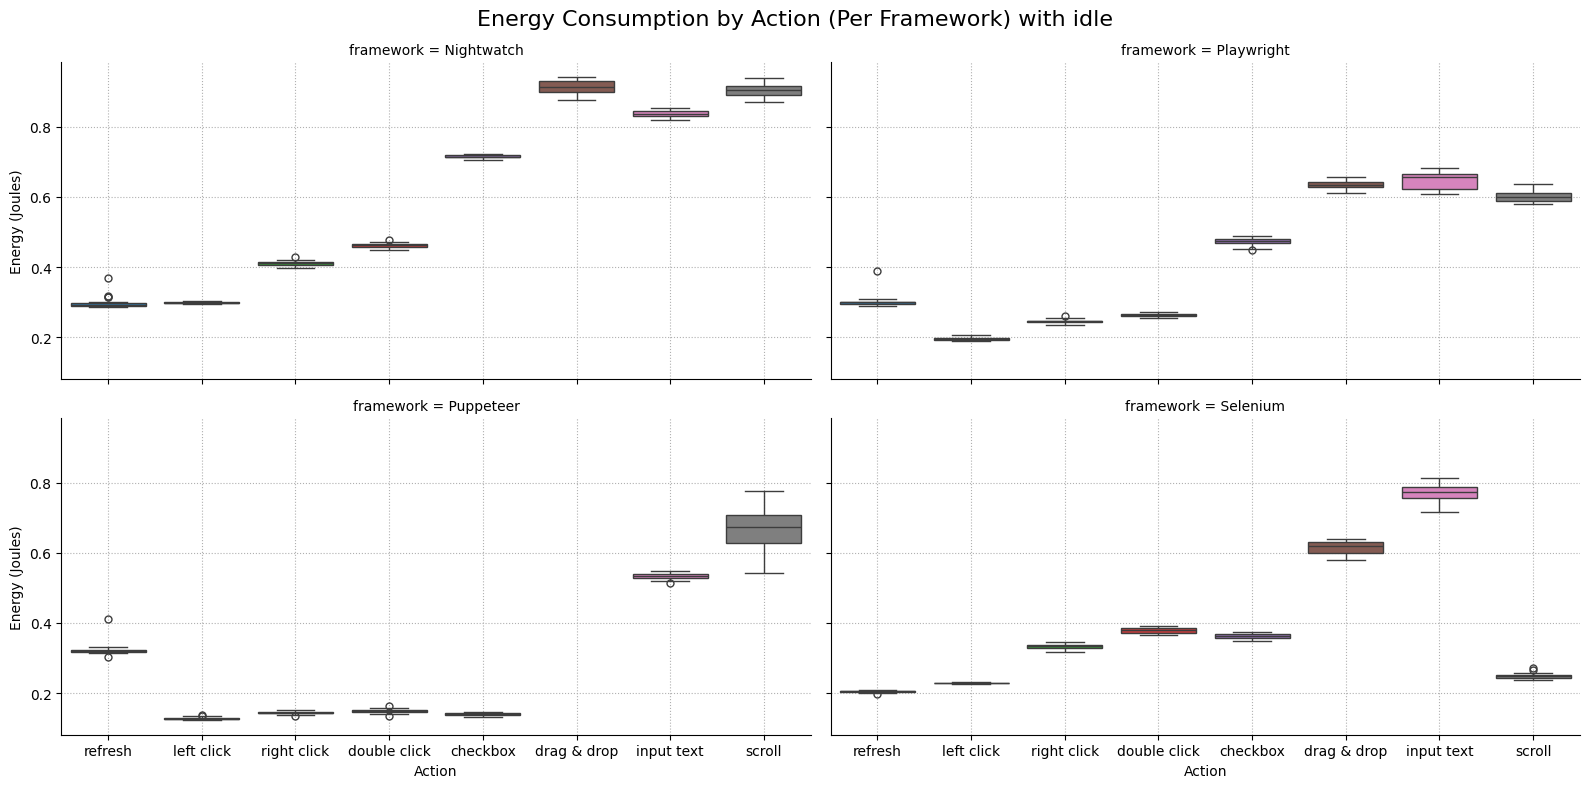

In [30]:
#do the same as above, but by each framework, instead of by action

# Create a separate boxplot per action using FacetGrid
g = sns.catplot(
    data=selected_energy_df,
    x="action_category", y="energy_action",
    col="framework",
    kind="box",
    hue="action_category",
    col_wrap=2,
    height=4, aspect=2,
)

for ax in g.axes.flat:
    ax.grid(True, linestyle=':', linewidth=0.8)
    #ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=8)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Energy Consumption by Action (Per Framework)", fontsize=16)
g.set_axis_labels("Action", "Energy (Joules)")
#plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/RQ1-boxplot-action.png')
plt.show()



# Create a separate boxplot per action using FacetGrid
g = sns.catplot(
    data=selected_energy_df,
    x="action_category", y="energy",
    col="framework",
    kind="box",
    hue="action_category",
    col_wrap=2,
    height=4, aspect=2
)

for ax in g.axes.flat:
    ax.grid(True, linestyle=':', linewidth=0.8)
    #ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=8)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Energy Consumption by Action (Per Framework) with idle", fontsize=16)
g.set_axis_labels("Action", "Energy (Joules)")
#plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/RQ1-boxplot-action-with-idle.png')
plt.show()

In [31]:
# Run Kruskal-Wallis per action using selected_energy_df

from scipy.stats import kruskal

# Define the shared actions for RQ2
shared_actions = [
    'checkbox', 'double click', 'drag & drop', 'input text',
    'left click', 'refresh', 'right click', 'scroll'
]

# Store results
rq2_results_manual = []

for action in shared_actions:
    subset = selected_energy_df[selected_energy_df['action_category'] == action]
    grouped = subset.groupby('framework')['energy_action']
    groups = [group.tolist() for _, group in grouped if len(group) > 2]

    if len(groups) > 1:
        stat, p = kruskal(*groups)
        rq2_results_manual.append({
            'action': action,
            'H-statistic': stat,
            'p-value': p,
            'Significant? (p < 0.05)': p < 0.05
        })

# Convert to DataFrame for display
rq2_results_manual_df = pd.DataFrame(rq2_results_manual)

In [32]:
rq2_results_manual_df




,action,H-statistic,p-value,Significant? (p < 0.05)
0,checkbox,130.319149,4.616316e-28,True
1,double click,130.319149,4.616316e-28,True
2,drag & drop,92.377420,8.719631e-21,True
3,input text,118.614902,1.533653e-25,True
4,left click,130.319149,4.616316e-28,True
5,refresh,114.237210,1.343698e-24,True
6,right click,130.319149,4.616316e-28,True
7,scroll,129.564446,6.713282e-28,True


In [33]:
rq2_results_manual_df.to_latex()

'\\begin{tabular}{llrrr}\n\\toprule\n & action & H-statistic & p-value & Significant? (p < 0.05) \\\\\n\\midrule\n0 & checkbox & 130.319149 & 0.000000 & True \\\\\n1 & double click & 130.319149 & 0.000000 & True \\\\\n2 & drag & drop & 92.377420 & 0.000000 & True \\\\\n3 & input text & 118.614902 & 0.000000 & True \\\\\n4 & left click & 130.319149 & 0.000000 & True \\\\\n5 & refresh & 114.237210 & 0.000000 & True \\\\\n6 & right click & 130.319149 & 0.000000 & True \\\\\n7 & scroll & 129.564446 & 0.000000 & True \\\\\n\\bottomrule\n\\end{tabular}\n'

In [34]:
# RQ3

In [35]:
# Export the full energy dataset (unfiltered) for R-side processing
energy_df[['framework', 'action_category', 'energy_action']].to_csv("art_anova_input_full.csv", index=False)



In [36]:
# Go to R and run the file

In [37]:
# RQ4

In [38]:
energy_df['action_category'].unique()

array(['refresh', 'left click', 'right click', 'double click', 'checkbox',
       'drag & drop', 'input text', 'scroll', 'refresh with clear',
       'left click with clear and no action api',
       'left click with action api', 'input text, no backspaces',
       'input text, with backspace, no clear'], dtype=object)

In [39]:
# This research question is for Selenium
selenium_df = energy_df[energy_df['framework'] == 'Selenium']

# Define variant groups for RQ4
rq4_variants = {
    'refresh': [
        'refresh',
        'refresh with clear'
    ],
    'left click': [
        'left click',
        'left click with clear and no action api',
        'left click with no action api'
    ],
    'input text': [
        'input text',
        'input text, no backspaces',
        'input text, with backspace, no clear'
    ]
}

# Filter Selenium data to only these action variants
filtered_rq4 = selenium_df[selenium_df['action_category'].isin(
    sum(rq4_variants.values(), [])
)]

# Map to a consolidated group name for each main action
def get_grouped_action(row):
    for key, variants in rq4_variants.items():
        if row['action_category'] in variants:
            return key
    return None

filtered_rq4 = filtered_rq4.copy()
filtered_rq4['grouped_action'] = filtered_rq4.apply(get_grouped_action, axis=1)


In [40]:
filtered_rq4

,category,framework,ID,event,number_of_iterations_pr_run,energy_pr_run,energy,time_pr_run,time,start_time,action_category_no,action_category,power_sleep,energy_idle,energy_sleep,energy_action,grouped_action
805,1,Selenium,Selenium,SeleniumEC/Tests/action1_clear.js,140,42.100000,0.300714,14956,106.828571,1970-01-01 00:03:56.084,0,refresh with clear,1.85,6.512638,0.197633,0.254195,refresh
806,2,Selenium,Selenium,SeleniumEC/Tests/action1_clear.js,140,31.202800,0.222877,10244,73.171429,1970-01-01 00:06:11.084,0,refresh with clear,1.85,6.512638,0.135367,0.176358,refresh
807,3,Selenium,Selenium,SeleniumEC/Tests/action1_clear.js,140,31.471925,0.224799,10241,73.150000,1970-01-01 00:08:21.085,0,refresh with clear,1.85,6.512638,0.135328,0.178281,refresh
808,4,Selenium,Selenium,SeleniumEC/Tests/action1_clear.js,140,31.224700,0.223034,10204,72.885714,1970-01-01 00:10:32.085,0,refresh with clear,1.85,6.512638,0.134839,0.176515,refresh
809,5,Selenium,Selenium,SeleniumEC/Tests/action1_clear.js,140,31.175825,0.222684,10227,73.050000,1970-01-01 00:12:42.084,0,refresh with clear,1.85,6.512638,0.135142,0.176166,refresh
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1220,416,Selenium,Selenium,SeleniumEC/Tests/action7.js,60,45.239575,0.753993,16982,283.033333,1970-01-01 17:21:34.071,11,input text,1.85,6.512638,0.523612,0.645449,input text
1221,417,Selenium,Selenium,SeleniumEC/Tests/action7.js,60,45.270975,0.754516,16964,282.733333,1970-01-01 17:23:51.871,11,input text,1.85,6.512638,0.523057,0.645972,input text
1222,418,Selenium,Selenium,SeleniumEC/Tests/action7.js,60,47.417250,0.790287,17185,286.416667,1970-01-01 17:26:08.370,11,input text,1.85,6.512638,0.529871,0.681744,input text
1223,419,Selenium,Selenium,SeleniumEC/Tests/action7.js,60,45.463875,0.757731,16994,283.233333,1970-01-01 17:28:26.171,11,input text,1.85,6.512638,0.523982,0.649187,input text


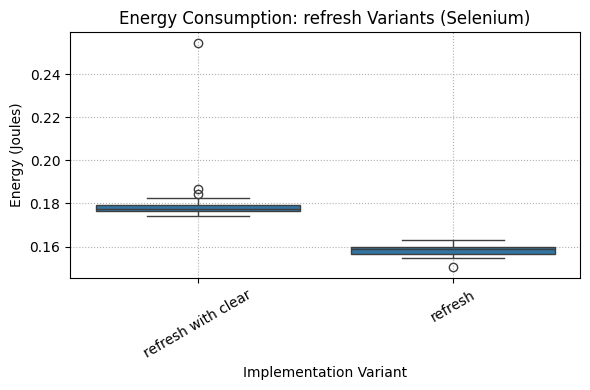

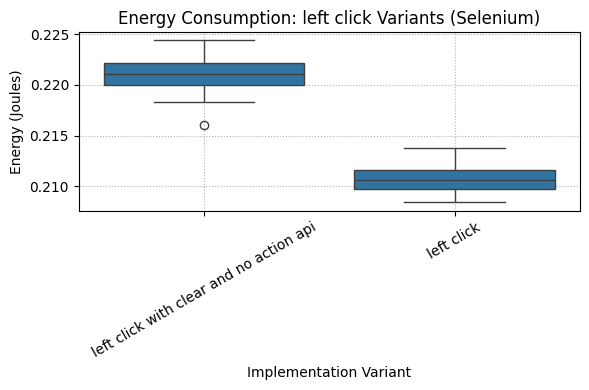

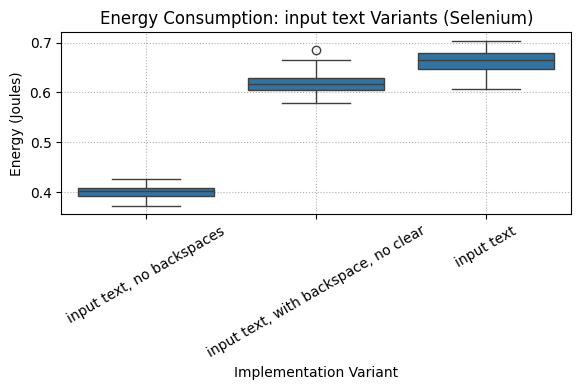

In [41]:
# Generate one plot per grouped action with true variant labels on x-axis

# Get the unique grouped actions
unique_groups = filtered_rq4['grouped_action'].unique()

# Plot one at a time
import matplotlib.pyplot as plt
import seaborn as sns

for group in unique_groups:
    subset = filtered_rq4[filtered_rq4['grouped_action'] == group]
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=subset, x='action_category', y='energy_action')
    plt.title(f"Energy Consumption: {group} Variants (Selenium)")
    plt.xlabel("Implementation Variant")
    plt.ylabel("Energy (Joules)")
    plt.xticks(rotation=30)
    plt.grid(True, linestyle=':', linewidth=0.8)
    plt.tight_layout()
    plt.savefig(f'figures/RQ4-{group}-boxplot.png')
    plt.show()


In [42]:
# Prepare results container
kruskal_results = []

# Loop over each grouped action (e.g., 'input text', 'left click', 'refresh')
for group in filtered_rq4['grouped_action'].unique():
    subset = filtered_rq4[filtered_rq4['grouped_action'] == group]
    # Group energy by variant
    grouped_variants = [group_df['energy'].values for _, group_df in subset.groupby('action_category')]
    if len(grouped_variants) > 1:
        stat, p = kruskal(*grouped_variants)
        kruskal_results.append({
            'action': group,
            'H-statistic': stat,
            'p-value': p,
            'Significant (p < 0.05)': p < 0.05
        })

# Create a DataFrame with the results
kruskal_df = pd.DataFrame(kruskal_results)


In [43]:
display(kruskal_df)

,action,H-statistic,p-value,Significant (p < 0.05)
0,refresh,51.761469,6.266968e-13,True
1,left click,51.760563,6.269859e-13,True
2,input text,82.404559,1.276666e-18,True


In [44]:
kruskal_df.to_latex()

'\\begin{tabular}{llrrr}\n\\toprule\n & action & H-statistic & p-value & Significant (p < 0.05) \\\\\n\\midrule\n0 & refresh & 51.761469 & 0.000000 & True \\\\\n1 & left click & 51.760563 & 0.000000 & True \\\\\n2 & input text & 82.404559 & 0.000000 & True \\\\\n\\bottomrule\n\\end{tabular}\n'

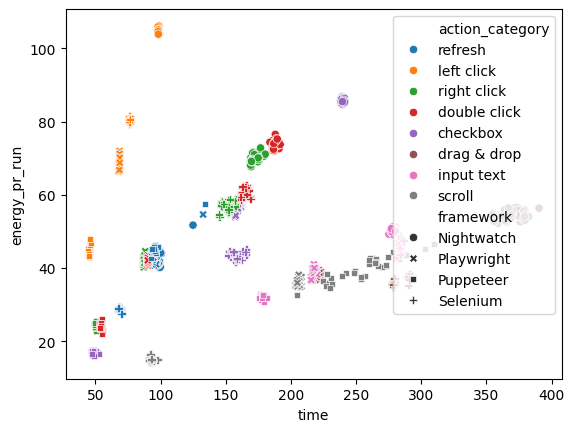

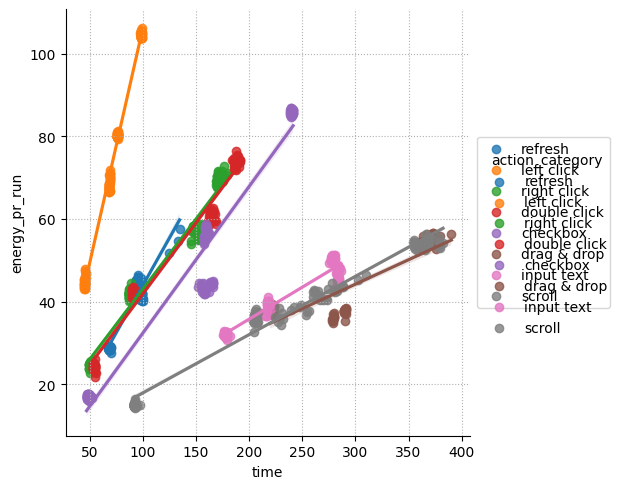

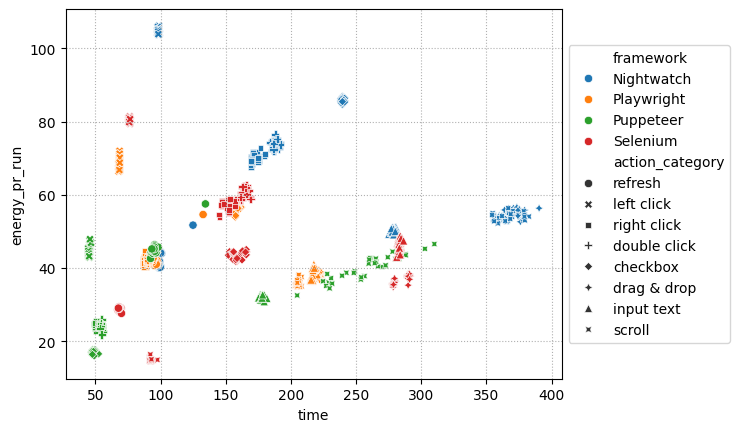

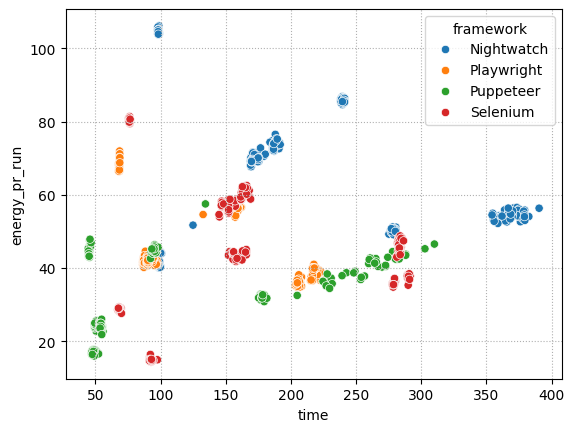

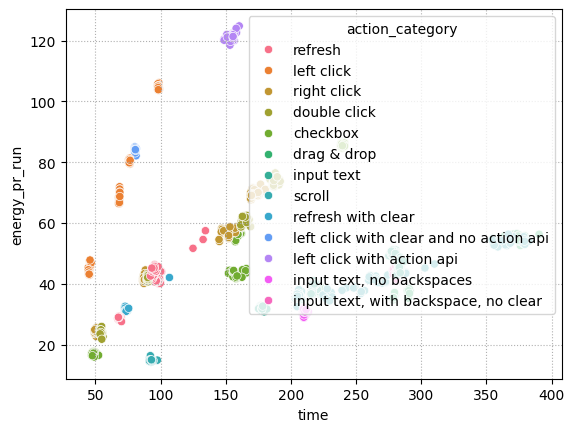

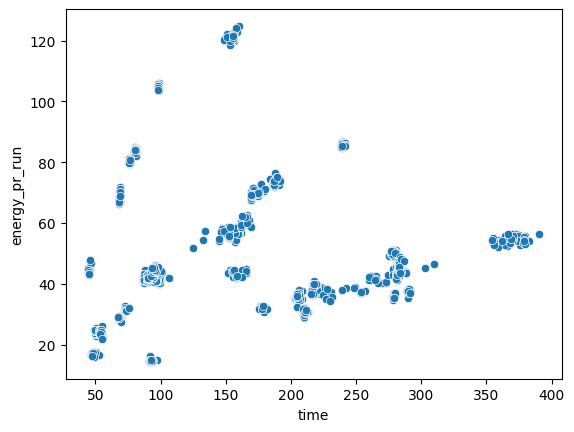

In [45]:
# sns.scatterplot(data=selected_energy_df,y="energy_pr_run", x="time", hue='action_category', col="framework")
sns.scatterplot(data=selected_energy_df,y="energy_pr_run", x="time", hue='action_category', style="framework")
g = sns.lmplot(data=selected_energy_df,y="energy_pr_run", x="time", hue='action_category')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle=':', linewidth=0.8)
plt.show()


sns.scatterplot(data=selected_energy_df,y="energy_pr_run", x="time", style='action_category', hue="framework")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle=':', linewidth=0.8)
plt.show()

sns.scatterplot(data=selected_energy_df,y="energy_pr_run", x="time", hue='framework')
plt.grid(True, linestyle=':', linewidth=0.8)
plt.show()

# Energy and Time
sns.scatterplot(data=energy_df,y="energy_pr_run", x="time", hue='action_category')
plt.grid(True, linestyle=':', linewidth=0.8)
plt.show()
# correlation (inverse - actions vs frameworks)

# Energy and Time
sns.scatterplot(data=energy_df,y="energy_pr_run", x="time")
plt.show()

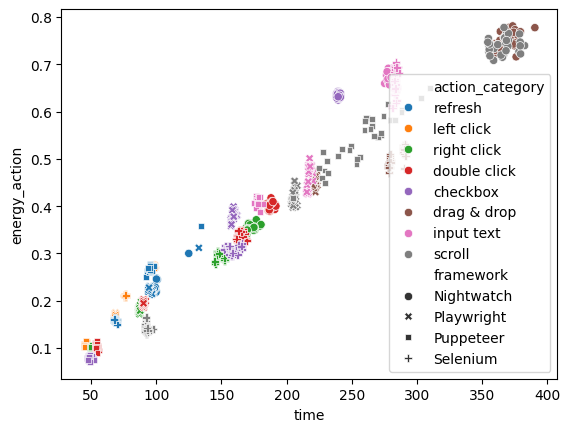

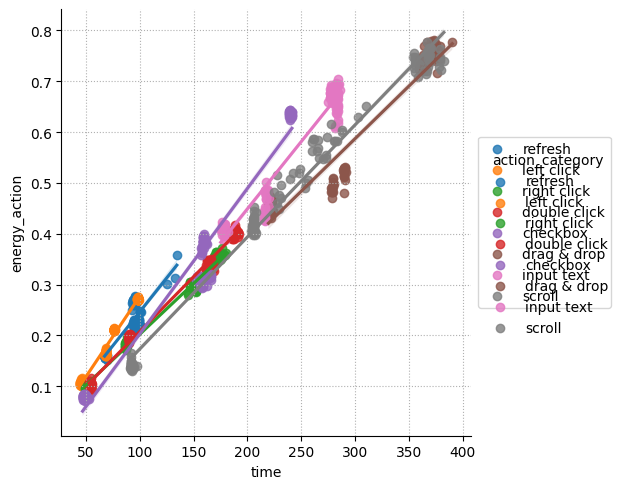

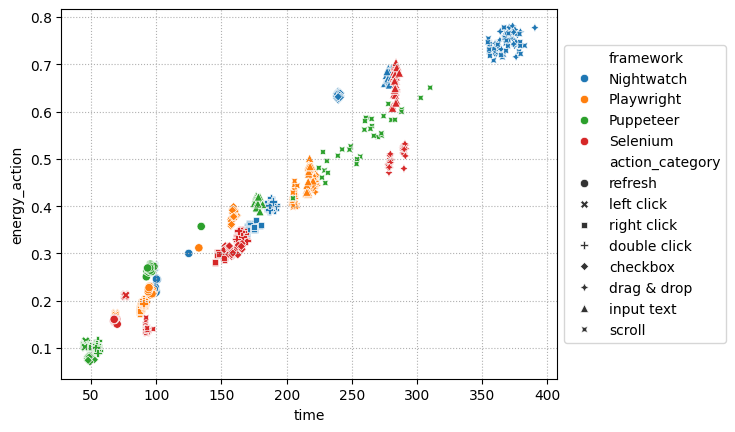

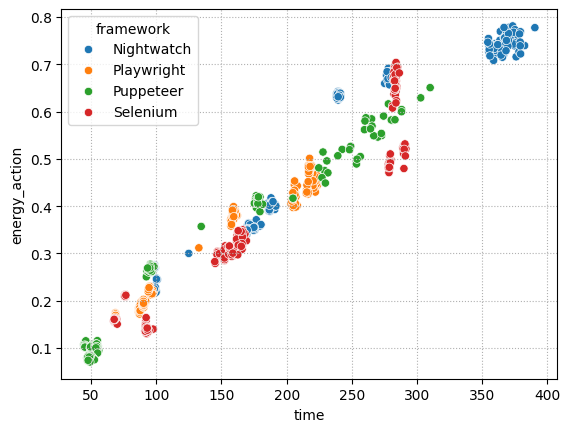

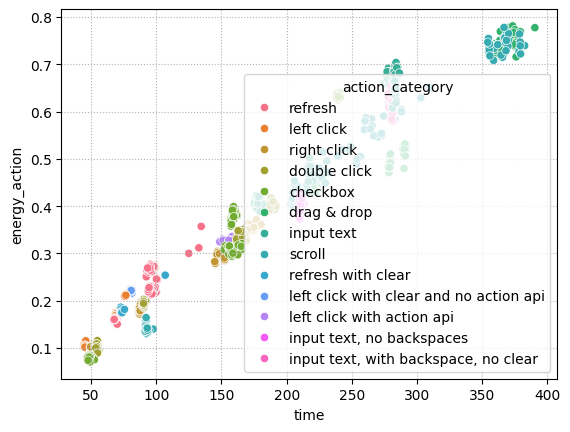

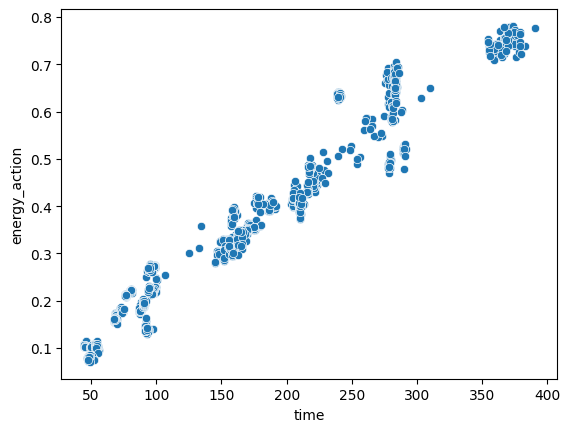

In [46]:
sns.scatterplot(data=selected_energy_df,y="energy_action", x="time", hue='action_category', style="framework")
g = sns.lmplot(data=selected_energy_df,y="energy_action", x="time", hue='action_category')     
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle=':', linewidth=0.8)
plt.show()


sns.scatterplot(data=selected_energy_df,y="energy_action", x="time", style='action_category', hue="framework")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle=':', linewidth=0.8)
plt.show()

sns.scatterplot(data=selected_energy_df,y="energy_action", x="time", hue='framework')
plt.grid(True, linestyle=':', linewidth=0.8)
plt.show()

# Energy and Time
sns.scatterplot(data=energy_df,y="energy_action", x="time", hue='action_category')
plt.grid(True, linestyle=':', linewidth=0.8)
plt.show()
# correlation (inverse - actions vs frameworks)

# Energy and Time
sns.scatterplot(data=energy_df,y="energy_action", x="time")
plt.show()